<a href="https://colab.research.google.com/github/nekhaasen/Spotify-Artists-EDA/blob/main/Spotify_Artists_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPLORATORY DATA ANALYSIS

LOADING THE DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("file.csv")
print(df.head())

          Artist     Sex        Country Langugage Primary Genre  Artist Type  \
0          Drake    Male         Canada   English       Hip-Hop         Solo   
1   Taylor Swift  Female  United States   English           Pop         Solo   
2      Bad Bunny    Male  United States   Spanish     Reggaeton         Solo   
3     The Weeknd    Male         Canada   English           R&B         Solo   
4  Justin Bieber    Male         Canada   English           Pop         Solo   

   Total Streams (in millions)  Lead Streams (in millions)  \
0                     137492.1                     94851.1   
1                     127861.0                    126177.3   
2                     125899.8                     82189.3   
3                      95703.2                     77189.4   
4                      78104.4                     48316.2   

   Feature Streams (in millions)  Solo Streams (in millions)  
0                        42640.9                     53323.9  
1                   

DATA EXPLORATION

In [ ]:
print(df.shape)
print(df.dtypes)

(500, 10)
Artist                            object
Sex                               object
Country                           object
Langugage                         object
Primary Genre                     object
 Artist Type                      object
Total Streams (in millions)      float64
Lead Streams (in millions)       float64
Feature Streams (in millions)    float64
Solo Streams (in millions)       float64
dtype: object


In [ ]:
print(df.describe())
print(df.info())

       Total Streams (in millions)  Lead Streams (in millions)  \
count                   500.000000                  497.000000   
mean                  16817.610200                12215.024145   
std                   14845.197632                11842.628550   
min                    6972.000000                    8.400000   
25%                    8768.175000                 6568.500000   
50%                   11923.250000                 8772.200000   
75%                   18020.050000                13579.300000   
max                  137492.100000               126177.300000   

       Feature Streams (in millions)  Solo Streams (in millions)  
count                     468.000000                  493.000000  
mean                     5001.377137                 8442.593915  
std                      6021.629551                 9605.072797  
min                         0.400000                    1.300000  
25%                       971.450000                 2755.300000  
50%

DATA CLEANING

In [ ]:
if 'Langugage' in df.columns:
  df.rename(columns={'Langugage':'Language'}, inplace=True)

In [ ]:
if 'Total Streams (in millions)' in df.columns:
  df.rename(columns={'Total Streams (in millions)' :'Total Streams'}, inplace=True)

In [ ]:
if 'Lead Streams (in millions)' in df.columns:
  df.rename(columns={'Lead Streams (in millions)' :'Lead Streams'}, inplace=True)

In [ ]:
if 'Solo Streams (in millions)' in df.columns:
  df.rename(columns={'Solo Streams (in millions)' :'Solo Streams'}, inplace=True)

In [ ]:
if 'Feature Streams (in millions)' in df.columns:
  df.rename(columns={'Feature Streams (in millions)' :'Feature Streams'}, inplace=True)

In [ ]:
df.head()

,Artist,Sex,Country,Language,Primary Genre,Artist Type,Total Streams,Lead Streams,Feature Streams,Solo Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,137492.1,94851.1,42640.9,53323.9
1,Taylor Swift,Female,United States,English,Pop,Solo,127861.0,126177.3,1683.8,113421.5
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,125899.8,82189.3,43710.5,48887.0
3,The Weeknd,Male,Canada,English,R&B,Solo,95703.2,77189.4,18513.8,51020.0
4,Justin Bieber,Male,Canada,English,Pop,Solo,78104.4,48316.2,29788.2,29638.3


In [ ]:
missing = df.isnull().sum()
print(missing)

Artist              0
Sex                 0
Country             0
Language            0
Primary Genre       0
 Artist Type        0
Total Streams       0
Lead Streams        3
Feature Streams    32
Solo Streams        7
dtype: int64


REPLACING MISSING VALUES

In [ ]:
df['Lead Streams'] = df['Lead Streams'].interpolate(method='linear')
df['Solo Streams'] = df['Solo Streams'].interpolate(method='linear')
df['Feature Streams'] = df['Feature Streams'].interpolate(method='linear')

In [ ]:
missing = df.isnull().sum()
print(missing)

Artist             0
Sex                0
Country            0
Language           0
Primary Genre      0
 Artist Type       0
Total Streams      0
Lead Streams       0
Feature Streams    0
Solo Streams       0
dtype: int64


EXPLORATORY DATA ANALYSIS

In [ ]:
df.sort_values(by="Artist", ascending=True).head(10)

,Artist,Sex,Country,Language,Primary Genre,Artist Type,Total Streams,Lead Streams,Feature Streams,Solo Streams
93,$uicideboy$,Male,United States,English,Hip-Hop,Group,21202.3,20357.3,851.6,16646.9
196,2 Chainz,Male,United States,English,Hip-Hop,Solo,13978.6,4090.4,9888.1,895.7
32,21 Savage,Male,United Kingdom,English,Hip-Hop,Solo,39024.3,15878.0,23155.6,7883.1
190,2Pac,Male,United States,English,Hip-Hop,Solo,14116.7,13659.9,462.4,5423.2
230,5 Seconds of Summer,Male,Australia,English,Rock,Group,12788.3,12025.6,766.3,11526.4
99,50 Cent,Male,United States,English,Hip-Hop,Solo,20444.6,14112.2,6342.0,8484.4
440,6LACK,Male,United States,English,R&B,Solo,7810.5,3575.2,4235.2,2342.1
408,6ix9ine,Male,United States,English,Hip-Hop,Solo,8240.2,6845.4,1394.8,2320.7
139,A Boogie Wit da Hoodie,Male,United States,English,Hip-Hop,Solo,16877.3,11425.9,5455.1,6395.3
83,A$AP Rocky,Male,United States,English,Hip-Hop,Solo,24217.2,14721.3,9504.3,6253.7


In [ ]:
print(df.corr(numeric_only=True))

                 Total Streams  Lead Streams  Feature Streams  Solo Streams
Total Streams         1.000000      0.924317         0.654794      0.771722
Lead Streams          0.924317      1.000000         0.333692      0.893867
Feature Streams       0.654794      0.333692         1.000000      0.176044
Solo Streams          0.771722      0.893867         0.176044      1.000000


NUMBER OF ARTISTS IN DIFFERENT GENRES

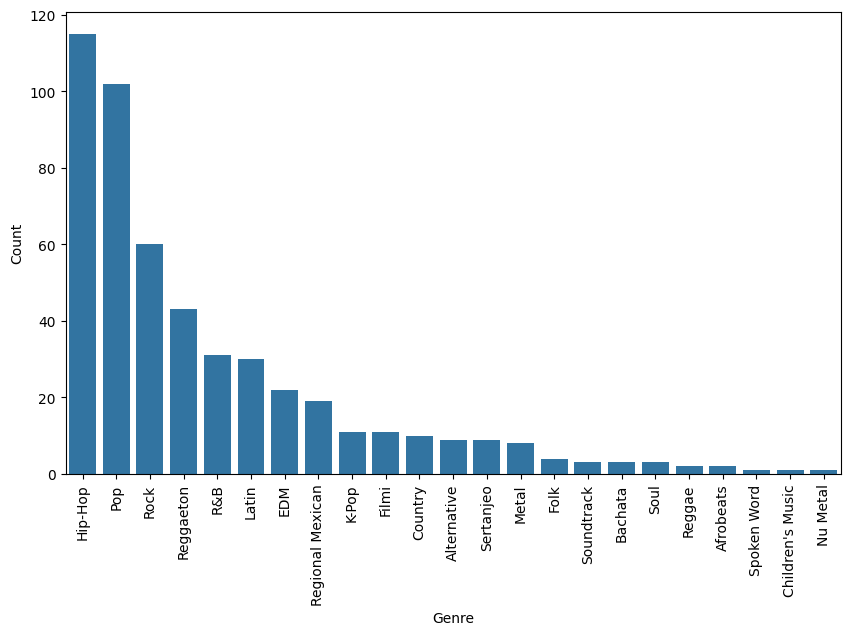

In [ ]:
genre=df['Primary Genre'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=genre.index,y=genre.values,legend=False)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


SOLO VS GROUP ARTISTS

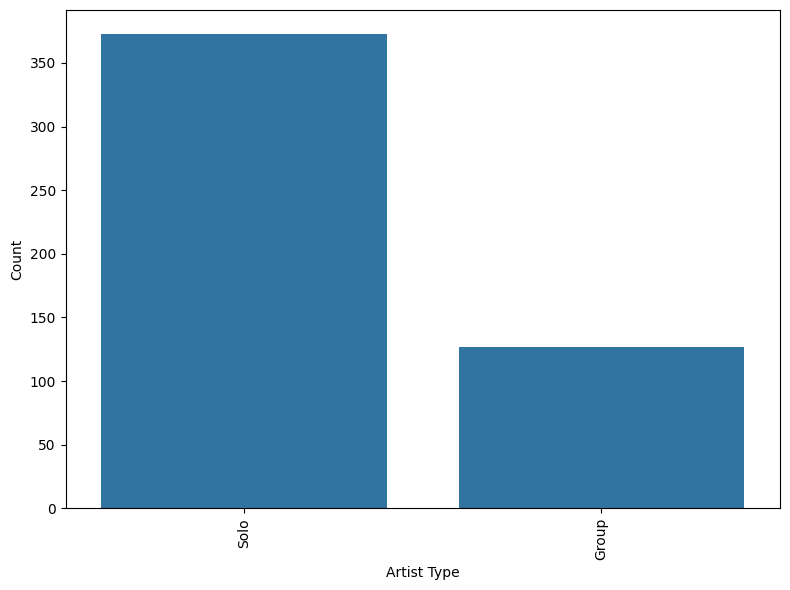

In [ ]:
art=df[' Artist Type'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=art.index,y=art.values,legend=False)
plt.xlabel('Artist Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
top_10 = df.sort_values(by='Total Streams', ascending=False).head(10)

In [ ]:
top_10.head()

,Artist,Sex,Country,Language,Primary Genre,Artist Type,Total Streams,Lead Streams,Feature Streams,Solo Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,137492.1,94851.1,42640.9,53323.9
1,Taylor Swift,Female,United States,English,Pop,Solo,127861.0,126177.3,1683.8,113421.5
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,125899.8,82189.3,43710.5,48887.0
3,The Weeknd,Male,Canada,English,R&B,Solo,95703.2,77189.4,18513.8,51020.0
4,Justin Bieber,Male,Canada,English,Pop,Solo,78104.4,48316.2,29788.2,29638.3


TOP 10 STREAMED ARTISTS ON SPOTIFY

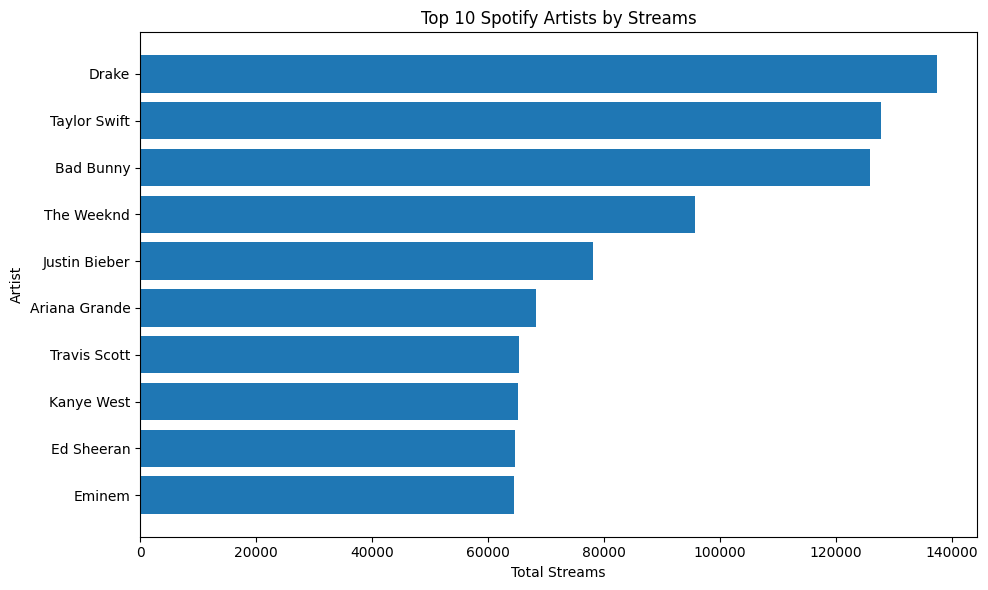

In [ ]:
top_10 = df.sort_values(by="Total Streams", ascending=False).head(10)

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(top_10["Artist"], top_10["Total Streams"])

plt.title("Top 10 Spotify Artists by Streams")
plt.xlabel("Total Streams")
plt.ylabel("Artist")

# Highest streamed artist at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

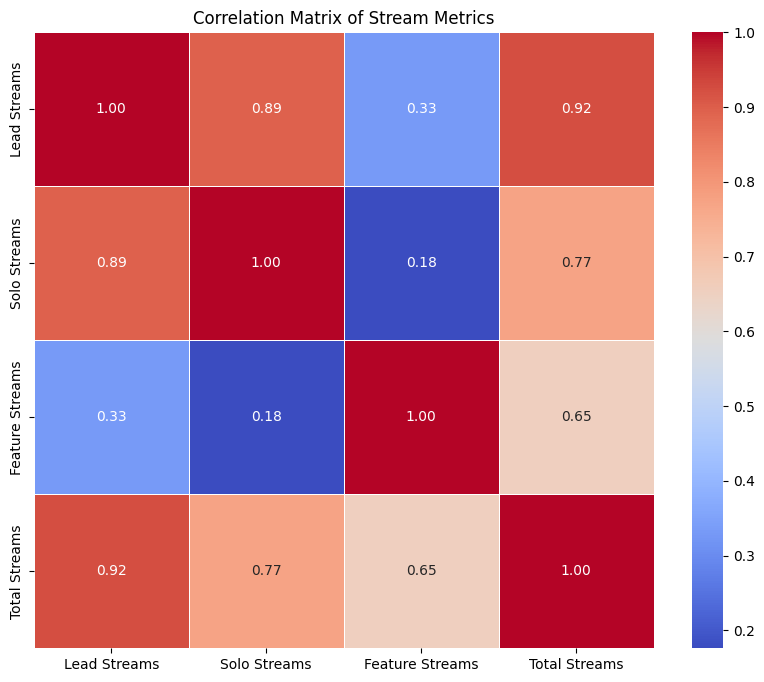

In [ ]:
num_cols = ['Lead Streams', 'Solo Streams', 'Feature Streams', 'Total Streams']
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Stream Metrics')
plt.show()